# MTH/CMSE 314
# IC18: QR Factorization
### <p style="text-align: right;"> &#9989; **Mikel Good** </p>

#### Goals
- Learning how to QR factorize a matrix with linearly independent columns.
- Learning how to QR factorize a matrix with linearly dependent columns.
- Solving a linear system using QR factorization instead of Gaussian elimination.

#### Please read the following before you begin: 

- <font color=#641e16> We recommended that you complete the After-Class Assignments (ACs) before starting the In-Class Assignments (ICs),
    
- <font color=#641e16> Keep your lecture notes handy for easy reference.

- <font color=#641e16> Use class time to collaborate with your group and get help from instructors, as IC solutions will not be provided.

---
## QR factorization (linearly independent columns)


If $A$ is $m\times n$ with linearly dependent columns. Then $$A=QR$$
where $Q$ is $m\times n$ and has orthonormal columns (which form a basis for col($A$)) and $R$ is $n\times n$ in an upper triangular matrix with positive entries in the main diagonal.


In [1]:
import numpy as np
import sympy as sym

We will write a function in python that has as input an $m\times n$ matrix $A$ and that
1. checks if the columns of $A$ are linearly independent. If not, the algorithm will end with a suitable message.
2. If the columns of $A$ are linearly independent, the function would return an $m\times n$ matrix $Q$ that has orthonormal columns and an $n\times n$ upper triangular invertible matrix $R$ with positive entries on its diagonal.

Note: DO NOT use numpy to get the matrices $Q$ and $R$.

Recall the projection function we have already seen:

In [2]:
def projection(v,u):
    u=np.array(u)
    v=np.array(v)
    if len(u)==len(v):
        return np.dot(u,v)/np.dot(u,u)*u
    else:
        print('The vectors are not of equal dimension')

and the Gram-Schmidt function that creates an orthonormal set from a given linearly independent one:

In [3]:
def ortho_GramSchmidt(A):
    # Get the transpose of A
    A=np.array(A)
    AT = A.T

    # Create a new empty matrix GT
    GT = np.zeros(AT.shape)

    # Loop over the rows of AT
    for i in range(AT.shape[0]):   # AT.shape[0]=len(AT)
        # Set the i-th row of GT to be the i-th row of AT
        GT[i] = AT[i]

        # Loop over the previous rows of GT
        for j in range(i):
            # Subtract the projection of AT[i] onto GT[j]
            GT[i] -= projection(AT[i],GT[j])
            
        # Normalize the vector by dividing it by its magnitude
        GT[i] /= np.linalg.norm(GT[i])

    # Transpose GT to get the orthogonal matrix G
    G = GT.T

    return G

&#9989; <font color=blue>**<font color=red>Do this:</font>** Now, complete the following block of code to write a ```qr_factorization()``` function:

In [21]:
# Fill in the ...:
def qr_factorization(A):
    A=np.array(A)
    I = np.zeros(A.shape)
    
    for i in range(A.shape[1]):
        I[i,i] = 1
        
    if np.allclose(sym.Matrix(A).rref()[0], I): #condition to check for linear independence of columns of A
        Q=ortho_GramSchmidt(A)
        R=Q.T@A
        return Q,R
    else:
        print('The columns of the matrix are not linearly independent')

&#9989; <font color=blue>**<font color=red>Do this:</font>** Test your function on the following matrix:

In [22]:
A=[[1,2],[1,1],[-1,1]]
qr_factorization(A)

(array([[ 0.57735027,  0.6172134 ],
        [ 0.57735027,  0.15430335],
        [-0.57735027,  0.77151675]]),
 array([[ 1.73205081e+00,  1.15470054e+00],
        [-4.44089210e-16,  2.16024690e+00]]))

&#9989; <font color=blue>**<font color=red>Do this:</font>** Do you get the expected answer? What are the disadvantages of using the Gram-Schmidt orthonormalization on a computer to QR factor a matrix?

Yes, I got the answer that I expected to get. The disadvantages of using the Gram-Schmidt orthonormalization on a computer to QR factor a matrix is that throughout the process, the final answer is subject to rounding errors. This is because all of the calculations are done with floating point numbers (when there is usually a lot of irrational roots that come with normalization). Because of this, the final answer might not be spot on with what a hand calculation would produce.

&#9989; <font color=blue>**Do this:</font>** Use your ```qr_factorization()``` function to factor $C=\begin{bmatrix}1&3&6\\1&2&2 \\1&3&8 \\1&2&4 \end{bmatrix}$. Then simplify the system $Cx=\begin{bmatrix}3 \\ -1 \\ 5 \\1 \end{bmatrix}$ using the QR factorization of $C$. Finally, solve the simplified system **by hand**.

In [ ]:
Qb = Q.T @ b

Rx = np.concatenate((R, Qb), axis=1)

x = sym.Matrix(Rx).rref()[0][:, -1]

In [45]:
C=[[1,3,6],[1,2,2],[1,3,8],[1,2,4]]
Cx = np.array([
    [3],
    [-1],
    [5],
    [1]
])

Q, R = qr_factorization(C)

#Put your answer here
Qx = Q.T @ Cx
Rx = np.concatenate((R, Qx), axis=1)

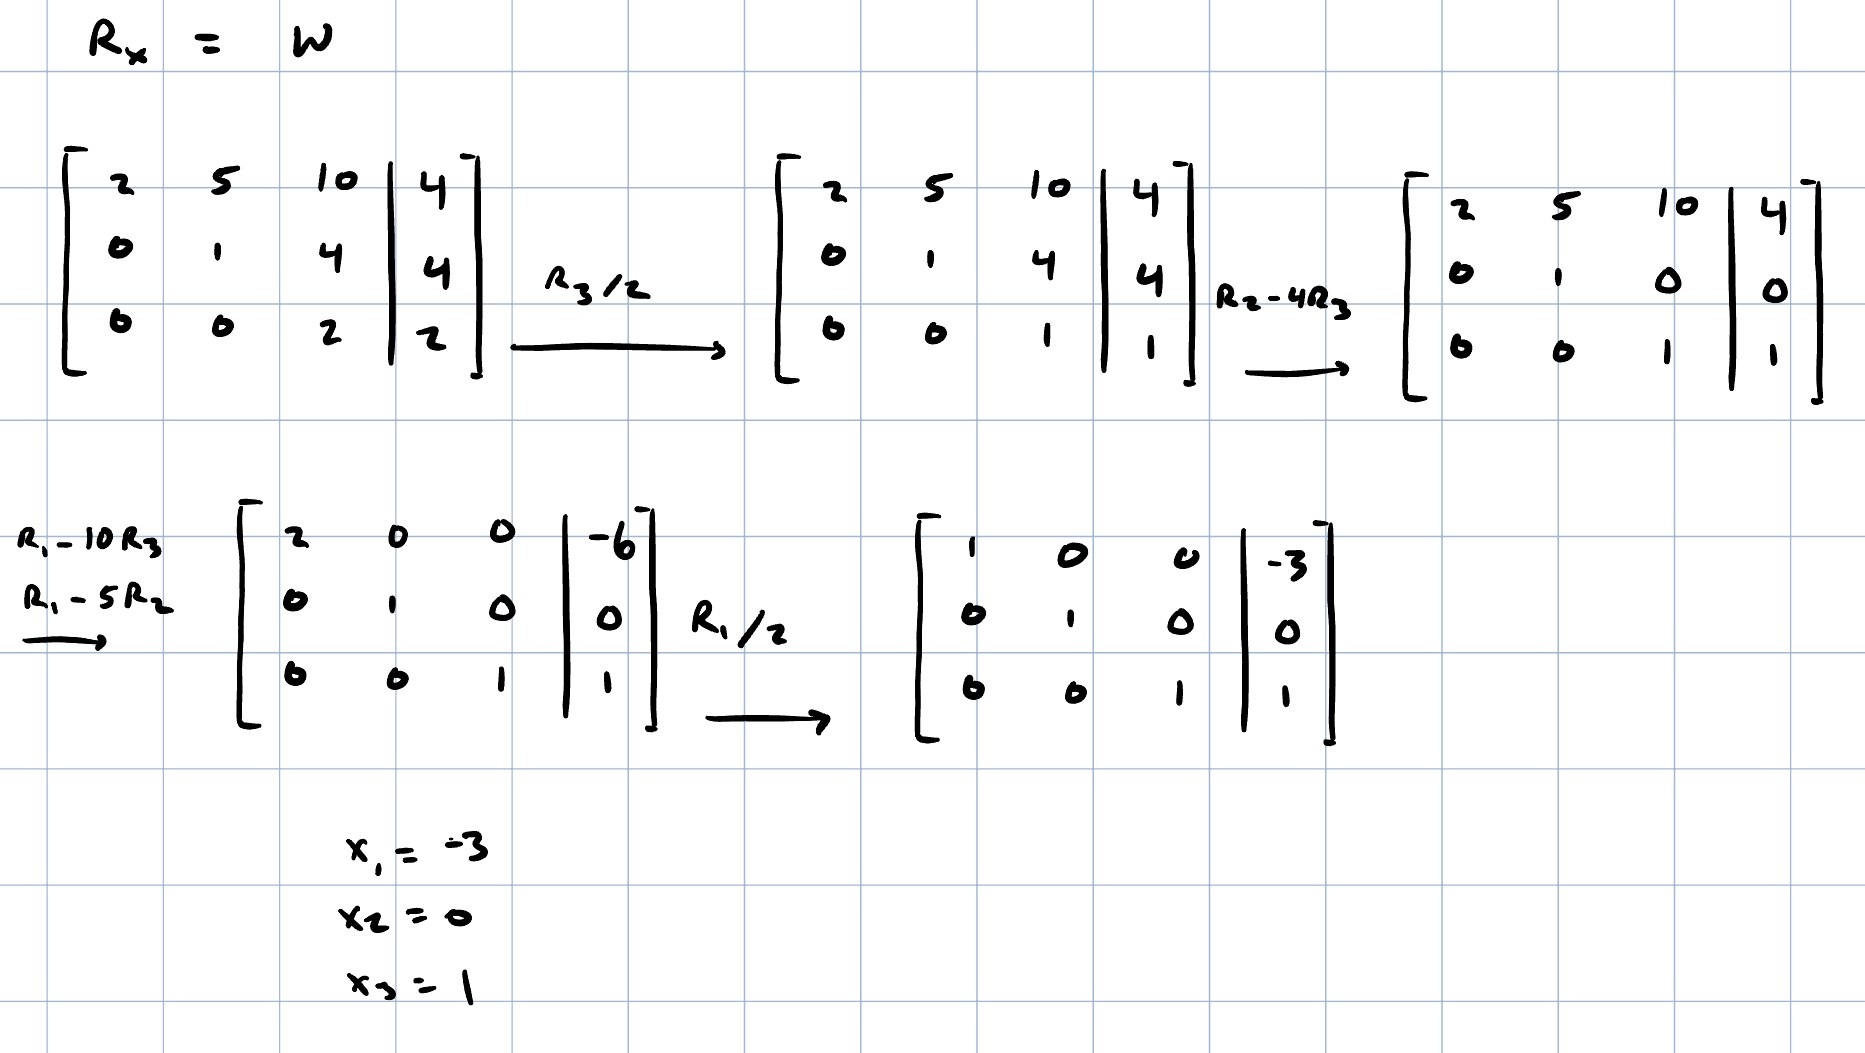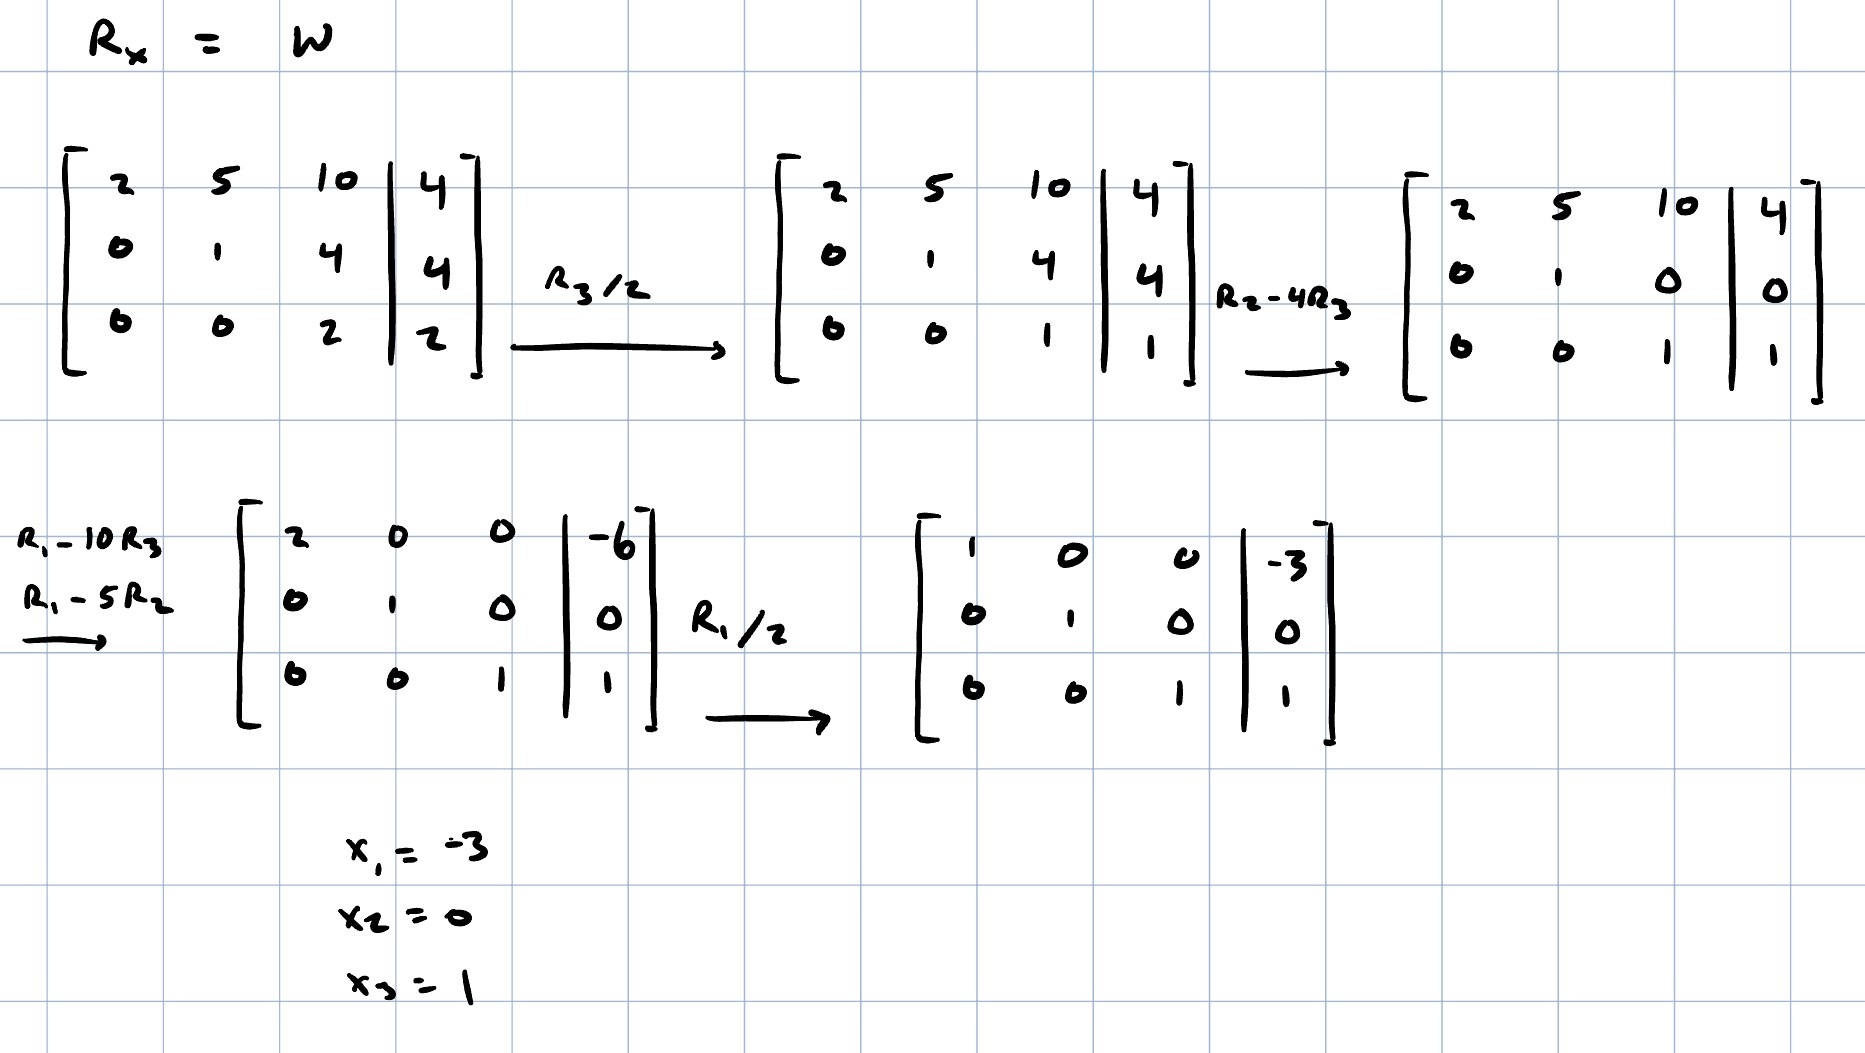

---
## QR factorization (linearly dependent columns)

Now, let's generalize the result above. Say that $A$ is $m\times n$, but it has linearly dependent columns. Say also that $\text{rank}(A)=r \leq \min\{m,n\}$. We will write it as $$A=QR$$
where $Q$ is $m\times r$ and has orthonormal columns and $R$ is $r\times n$ in an "upper staircase" form.

We get $Q$ by applying the generalized Gram-Schmidt algorithm that omits the linearly dependent columns. Recall,

In [47]:
def normalize_row(row):
    norm = np.linalg.norm(row)
    return row / norm if norm != 0 else row

def generalGS(A):
    # Get the transpose of A
    A=np.array(A)
    AT = A.T
    #Delete the zero elements of A
    A=A[~np.all(A == 0, axis=1)]
    
    #Set GT to be the first element of A.
    GT=np.array([AT[0]])
    
    #Keep a counter of the number of elements in GT. Currently we have 1.
    k=1
    
    # Loop over the rows of AT
    for i in range(1,AT.shape[0]):
        proj=AT[i]
        # Loop over the previous rows of GT to calculate the projection.
        for j in range(k):
            # Subtract the projection of AT[i] onto GT[j]
            proj =proj-projection(AT[i],GT[j])
        #If the element we got is not zero append it to the matrix.
        if not np.allclose(proj, np.zeros_like(proj)):   ## to deal with approximations
            GT=np.append(GT, [proj], axis=0)
            k+=1
            
          
#     Transpose GT to get the orthogonal matrix G
    G = GT.T
    # Normalize each row of G
    G_normalized = np.apply_along_axis(normalize_row, axis=0, arr=G)
    
    return G_normalized

&#9989; <font color=blue>**<font color=red>Do this:</font>** Now, complete the following block of code to write a function that executes the general QR factorization of a matrix as described above.

In [48]:
# Fill in the ...:
def qr_general(A):
    A=np.array(A)
    Q= generalGS(A) # Apply General Gram-Schmidt function to A
    R=Q.T@A
    return Q,R

&#9989; <font color=blue>**<font color=red>Do this:</font>** Apply this function to factorize the following matrices: $K$, $M$ and $C$ below.

In [52]:
B = [[1,1,1], [2,2,2],[1,1,-2],[2,2,-4],[1,1,3]]
K = np.array(B).T
sym.Matrix(K)

Matrix([
[1, 2,  1,  2, 1],
[1, 2,  1,  2, 1],
[1, 2, -2, -4, 3]])

In [53]:
qr_general(K)

(array([[ 0.57735027,  0.40824829],
        [ 0.57735027,  0.40824829],
        [ 0.57735027, -0.81649658]]),
 array([[ 1.73205081,  3.46410162,  0.        ,  0.        ,  2.88675135],
        [ 0.        ,  0.        ,  2.44948974,  4.89897949, -1.63299316]]))

In [54]:
M = np.array([[1,1,1],[1,1,1],[1,-2,3]])
sym.Matrix(M)

Matrix([
[1,  1, 1],
[1,  1, 1],
[1, -2, 3]])

In [55]:
qr_general(M)

(array([[ 0.57735027,  0.40824829],
        [ 0.57735027,  0.40824829],
        [ 0.57735027, -0.81649658]]),
 array([[ 1.73205081,  0.        ,  2.88675135],
        [ 0.        ,  2.44948974, -1.63299316]]))

In [56]:
C=[[1,3,6],[1,2,2],[1,3,8],[1,2,4]]
sym.Matrix(C)

Matrix([
[1, 3, 6],
[1, 2, 2],
[1, 3, 8],
[1, 2, 4]])

In [57]:
qr_general(C)

(array([[ 0.5,  0.5, -0.5],
        [ 0.5, -0.5, -0.5],
        [ 0.5,  0.5,  0.5],
        [ 0.5, -0.5,  0.5]]),
 array([[ 2.,  5., 10.],
        [ 0.,  1.,  4.],
        [ 0.,  0.,  2.]]))

In [58]:
D=np.array([[1,3,3],[1,2,2],[1,3,3],[1,2,2]])
sym.Matrix(D)

Matrix([
[1, 3, 3],
[1, 2, 2],
[1, 3, 3],
[1, 2, 2]])

In [59]:
qr_general(D)

(array([[ 0.5,  0.5],
        [ 0.5, -0.5],
        [ 0.5,  0.5],
        [ 0.5, -0.5]]),
 array([[2., 5., 5.],
        [0., 1., 1.]]))

In [60]:
N = np.array([[1,2,2],[1,1,-1],[1,1,0]])
sym.Matrix(N)

Matrix([
[1, 2,  2],
[1, 1, -1],
[1, 1,  0]])

In [61]:
Q1, R1= qr_general(N)
sym.Matrix(Q1)

Matrix([
[0.577350269189626,  0.816496580927726, -6.2803698347351e-16],
[0.577350269189626, -0.408248290463863,   -0.707106781186548],
[0.577350269189626, -0.408248290463863,    0.707106781186547]])

In [62]:
np.round(R1).astype(int)

array([[2, 2, 1],
       [0, 1, 2],
       [0, 0, 1]])

---
## Congratulations, you're done!
## Before you close or submit this In-Class Assignment, please make sure of a few things:
- Save your work (Ctrl + S) and export the notebook as a .pdf (Ctrl/Command + P → Save as PDF), or use an online ipynb to pdf converter if that fails.
- Ensure images render correctly in the PDF; if not, use
  ``` 
  from IPython.display import display, Image
  display(Image(filename="a.jpg", height=400, width=400))
  ``` 
  This works for JPGs only.
- Verify the PDF contents before submitting — make sure it is not empty and includes all material.
